In [1]:
import numpy as np
import trimesh
import matplotlib.pyplot as plt
import torch
import torchvision.transforms as transforms
from torchvision.models import resnet18, ResNet18_Weights

In [2]:
def load_and_sample_mesh_with_normals(filepath, num_points=50000):
    """
        This function loads an .off file, samples the object with points, and calculates normals
        Returns:
            - X : (3 x n) matrix, each column is a point in 3D
            - normals: (3 x n) matrix, each column is the direction of normal vector at the points
    """
    mesh = trimesh.load(filepath, force='mesh')
    
    # trimesh.sample returns the points and the indices of the faces they were sampled from
    samples, face_indices = trimesh.sample.sample_surface(mesh, num_points)
    
    X = samples.T  # Shape: (3, N)
    
    # Extract the normals for those specific faces
    normals = mesh.face_normals[face_indices].T  # Shape: (3, N)
    
    # Normalize the normal vectors just to be safe
    normals = normals / np.linalg.norm(normals, axis=0, keepdims=True)
    
    return X, normals

X, normals = load_and_sample_mesh_with_normals("./chair_0001.off", num_points=50000)
print(X.shape)
print(normals.shape)

(3, 50000)
(3, 50000)


In [3]:
def generate_view_matrix(theta_x, theta_y):
    """Creates a 3x2 orthogonal matrix by taking the first two columns of a rotation matrix."""
    Rx = np.array([
        [1, 0, 0],
        [0, np.cos(theta_x), np.sin(theta_x)],
        [0, -np.sin(theta_x), np.cos(theta_x)]
    ])
    Ry = np.array([
        [np.cos(theta_y), np.sin(theta_y), 0],
        [-np.sin(theta_y), np.cos(theta_y), 0],
        [0, 0, 1],
    ])
    R = Ry @ Rx
    return R[:, :2] # U \in St(2, 3)


U = generate_view_matrix(np.pi * (0.4), -np.pi * 0.75)
U.shape

(3, 2)

(224, 224, 3)


/var/folders/v9/p596rfjn6f5cxry5bh_b_0cw0000gn/T/ipykernel_15419/1312965504.py:12: RuntimeWarning: divide by zero encountered in matmul
  depth = u3.T @ X
/var/folders/v9/p596rfjn6f5cxry5bh_b_0cw0000gn/T/ipykernel_15419/1312965504.py:12: RuntimeWarning: overflow encountered in matmul
  depth = u3.T @ X
/var/folders/v9/p596rfjn6f5cxry5bh_b_0cw0000gn/T/ipykernel_15419/1312965504.py:12: RuntimeWarning: invalid value encountered in matmul
  depth = u3.T @ X
/var/folders/v9/p596rfjn6f5cxry5bh_b_0cw0000gn/T/ipykernel_15419/1312965504.py:15: RuntimeWarning: divide by zero encountered in matmul
  intensity = normals.T @ u3  # Shape: (N,) # The dot product between the surface normals and the light vector
/var/folders/v9/p596rfjn6f5cxry5bh_b_0cw0000gn/T/ipykernel_15419/1312965504.py:15: RuntimeWarning: overflow encountered in matmul
  intensity = normals.T @ u3  # Shape: (N,) # The dot product between the surface normals and the light vector
/var/folders/v9/p596rfjn6f5cxry5bh_b_0cw0000gn/T/ipyke

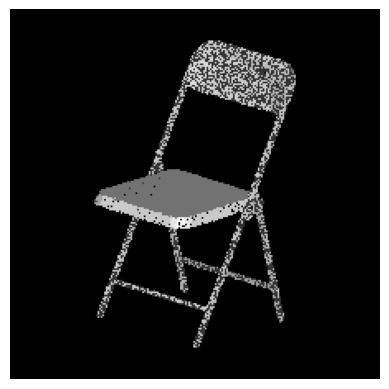

In [5]:
def render_shaded_orthogonal(X, normals, U, image_size=(224, 224), point_radius=0):
    """
        This function takes the X and the normals, and an orthogonal basis specified by U (3 x 2)
        Projects the points from the 2d projection of that orthogonal basis,
        Constructs the 2d projected image.

        Returns:
            - image: (image_size, 3)
    """    
    # u3 is the viewing direction (out of the screen), this is also the light source
    u3 = np.cross(U[:, 0], U[:, 1])  # this is the projection matrix onto the column space of U 
    depth = u3.T @ X 
    
    # Calculate Lambertian shading intensity
    intensity = normals.T @ u3  # Shape: (N,) # The dot product between the surface normals and the light vector
    
    # Clip values below 0 (surfaces facing away from the light) and add a small ambient baseline (e.g., 0.2) so shadows aren't pitch black
    ambient = 0.2
    intensity = np.clip(intensity, 0, 1) * (1 - ambient) + ambient    
    colors = np.repeat(intensity[np.newaxis, :], 3, axis=0)      # Broadcast the scalar intensity to RGB grayscale channels: Shape (3, N)

    margin = 0.1
    X_2d = U.T @ X  # 2d projection of points in X, Shape: (2, N)
    x_min, x_max, y_min, y_max = X_2d[0].min(), X_2d[0].max(), X_2d[1].min(), X_2d[1].max()
    dx, dy = x_max - x_min, y_max - y_min
    max_range = max(dx, dy)  # defining the grid sizes
    
    x_offset = (max_range - dx) / 2 # offset is used to define centers of each pixel grid
    y_offset = (max_range - dy) / 2
    
    xs = np.round((X_2d[0] - x_min + x_offset + margin*max_range) / (max_range * (1 + 2*margin)) * (image_size[0] - 1)).astype(int)
    ys = np.round((X_2d[1] - y_min + y_offset + margin*max_range) / (max_range * (1 + 2*margin)) * (image_size[1] - 1)).astype(int)
    
    # Splatting (Thickening points into squares, if needed)
    if point_radius > 0:
        offsets = np.arange(-point_radius, point_radius + 1)
        grid_x, grid_y = np.meshgrid(offsets, offsets)
        offset_x, offset_y = grid_x.flatten(), grid_y.flatten()
        
        xs = (xs[:, None] + offset_x[None, :]).flatten()
        ys = (ys[:, None] + offset_y[None, :]).flatten()
        depth = np.repeat(depth, len(offset_x))
        colors_expanded = np.repeat(colors, len(offset_x), axis=1)
    else:
        colors_expanded = colors
        
    valid = (xs >= 0) & (xs < image_size[0]) & (ys >= 0) & (ys < image_size[1])
    xs, ys, depth, colors_valid = xs[valid], ys[valid], depth[valid], colors_expanded[:, valid]
    
    # Z-Buffer sort
    sort_idx = np.argsort(depth)
    xs_sorted, ys_sorted, colors_sorted = xs[sort_idx], ys[sort_idx], colors_valid[:, sort_idx]
    
    image = np.zeros((image_size[1], image_size[0], 3))
    image[ys_sorted, xs_sorted] = colors_sorted.T
    
    return image


U = generate_view_matrix(np.pi * (0.4), -np.pi * 0.75)  # generate (3, 2) orthogonal matrix
img = render_shaded_orthogonal(X, normals, U)  # project 3d points and get image
print(img.shape)

plt.imshow(img)
plt.axis('off')
plt.show()

In [7]:
# pass the model into Resnet to evaluate objective function
device = "cpu"
normalizer = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
model = resnet18(weights=ResNet18_Weights.DEFAULT).to(device)  # load a trained ResNet model
model.eval()  # convert to eval mode

class_names = ResNet18_Weights.DEFAULT.meta["categories"]  # list of resnet categories
print(class_names[:10])

['tench', 'goldfish', 'great white shark', 'tiger shark', 'hammerhead', 'electric ray', 'stingray', 'cock', 'hen', 'ostrich']


In [12]:
# find true indices for chair / related to chair
for i, name in enumerate(class_names):
    if "chair" in name:
        print(f"Id: {i}, Label: {name}")

Id: 423, Label: barber chair
Id: 559, Label: folding chair
Id: 765, Label: rocking chair


Objective Value: -0.3019471338484436
Top 5 Predictions:
1: Label id: 307, weevil (0.3048)
2: Label id: 411, apron (0.1183)
3: Label id: 303, long-horned beetle (0.0892)
4: Label id: 317, leafhopper (0.0383)
5: Label id: 512, corkscrew (0.0341)


/var/folders/v9/p596rfjn6f5cxry5bh_b_0cw0000gn/T/ipykernel_15419/1312965504.py:12: RuntimeWarning: divide by zero encountered in matmul
  depth = u3.T @ X
/var/folders/v9/p596rfjn6f5cxry5bh_b_0cw0000gn/T/ipykernel_15419/1312965504.py:12: RuntimeWarning: overflow encountered in matmul
  depth = u3.T @ X
/var/folders/v9/p596rfjn6f5cxry5bh_b_0cw0000gn/T/ipykernel_15419/1312965504.py:12: RuntimeWarning: invalid value encountered in matmul
  depth = u3.T @ X
/var/folders/v9/p596rfjn6f5cxry5bh_b_0cw0000gn/T/ipykernel_15419/1312965504.py:15: RuntimeWarning: divide by zero encountered in matmul
  intensity = normals.T @ u3  # Shape: (N,) # The dot product between the surface normals and the light vector
/var/folders/v9/p596rfjn6f5cxry5bh_b_0cw0000gn/T/ipykernel_15419/1312965504.py:15: RuntimeWarning: overflow encountered in matmul
  intensity = normals.T @ u3  # Shape: (N,) # The dot product between the surface normals and the light vector
/var/folders/v9/p596rfjn6f5cxry5bh_b_0cw0000gn/T/ipyke

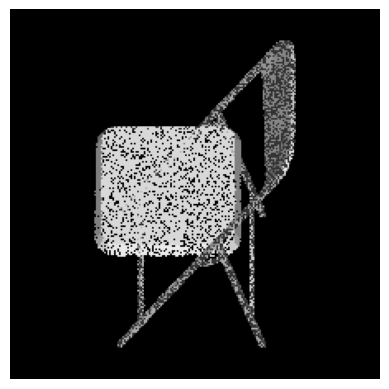

In [20]:
# apply resnet with a random orthogonal matrix
U = generate_view_matrix(np.pi * (0.2), -np.pi * 0.5)  # THIS IS MY ORTHOGONAL MATRIX, THIS CAN BE CHANGED
img_np = render_shaded_orthogonal(X, normals, U)
img_tensor = torch.from_numpy(img_np).permute(2, 0, 1).float()  # convert numpy to pytorch
input_tensor = normalizer(img_tensor).unsqueeze(0).to(device)

with torch.no_grad():
    logits = model(input_tensor)
    probs = torch.nn.functional.softmax(logits, dim=1)

TRUE_IDX = 559  # folding chair
objective = probs[0, TRUE_IDX].item() - probs[0].max().item()  # WE WILL AIM TO MINIMIZE THIS. => PROB of TRUE CLASS is small, PROB of other class is large
print(f"Objective Value: {objective}")  # objective = 0, true class is folding chair, for adversarial, we aim for large negative value

# Get the top 5 probabilities and their corresponding indices
top_probs, top_indices = torch.topk(probs, k=5, dim=1)
print("Top 5 Predictions:")
for i in range(5):
    idx = top_indices[0, i].item()
    prob = top_probs[0, i].item()
    label = class_names[idx]
    print(f"{i+1}: Label id: {idx}, {label} ({prob:.4f})")


# let's also make a plot to show this viewpoint
plt.imshow(img_np)
plt.axis('off')
plt.show()